## SENTIMENT ANALYSIS MODEL - Logistic Regression


In [18]:
import os
import pandas as pd

# Read raw data
master_dir = os.path.dirname(os.getcwd())

#train dataset
file_dataset_train = os.path.join(master_dir,
                           "dataset",
                           "test_dataset_bilingual.csv")

#test dataset
train_df = pd.read_csv(file_dataset_train)

file_dataset_test = os.path.join(master_dir,
                           "dataset",
                           "train_dataset_bilingual.csv")

test_df = pd.read_csv(file_dataset_test)

#validate dataset
file_dataset_val = os.path.join(master_dir,
                           "dataset",
                           "validate_dataset_bilingual.csv")

val_df = pd.read_csv(file_dataset_val)


In [20]:
train_df.head(10)

,Author,Rating,Review,Restaurant,Location,Label,Language
0,Philomina Wilson,5,Saya suka pastri mereka. Salah satu yang terb...,Chef At Home,Kuching,Positive,Malay
1,Michael Cheng,5,A very enjoyable brunch in a beautiful cafe & ...,Tropique Café & Restaurant,JB,Positive,English
2,Keai Aishiteru,5,Beef noodles rm6 comfortable blh hold juak Ras...,Satok Fly Over Cafe,Kuching,Positive,English
3,michael ting,5,Tempat terbaik untuk mi segera. Tempat terbai...,Kim Joo 錦裕,Kuching,Positive,Malay
4,Tirath Khera,5,"I love the food here, especially the parantha ...",Restoran Moga Punjab,Ipoh,Positive,English
5,Stephanie Ong,5,"Suka Prawn Masak Lemak, campuran Pong Teh dan...",SamFu Restaurant,Melaka,Positive,Malay
6,Yip Fung Lee,1,I don’t know what Hong Kong-style snacks are. ...,Foh San Restaurant,Ipoh,Negative,English
7,Treemore Plant,4,Try the potato noodle,Korean BBQ Nam Moon,JB,Positive,English
8,Firdous Ah Khan,5,Kehormatan makanan. Syurga untuk kekasih buru...,Pakeeza Restaurant & Catering,Ipoh,Positive,Malay
9,Stephen Philip,5,Food is very good,Ipoh Tuck Kee Restaurant 德记炒粉专门店,Ipoh,Positive,English


In [ ]:
# test True for lightweight and False for real training
# test = True # {True, False}
test = False

# export models
exportModel = True #{True, False}

In [21]:
train_df = train_df[['Review', 'Rating']]
train_df.drop_duplicates(inplace=True)
train_df.reset_index(drop=True, inplace=True)

In [22]:
# Adding labels
def labelFunc(x):
    if int(x) > 3: 
        return 2 # positive
    elif int(x) < 3:
        return 0 # neutral
    elif int(x) == 3:
        return 1 # negative

def labelFunc2(x):
    "Only Postive & Negative"
    if int(x) > 3:
        return 1 # positive
    elif int(x) < 3:
        return 0 # negative
    elif int(x) == 3:
        return -1 # neutral


train_df["Label"] = train_df["Rating"].apply(labelFunc2)

In [23]:
train_df.head(20)

,Review,Rating,Label
0,Saya suka pastri mereka. Salah satu yang terb...,5,1
1,A very enjoyable brunch in a beautiful cafe & ...,5,1
2,Beef noodles rm6 comfortable blh hold juak Ras...,5,1
3,Tempat terbaik untuk mi segera. Tempat terbai...,5,1
4,"I love the food here, especially the parantha ...",5,1
5,"Suka Prawn Masak Lemak, campuran Pong Teh dan...",5,1
6,I don’t know what Hong Kong-style snacks are. ...,1,0
7,Try the potato noodle,4,1
8,Kehormatan makanan. Syurga untuk kekasih buru...,5,1
9,Food is very good,5,1


### check class imbalance

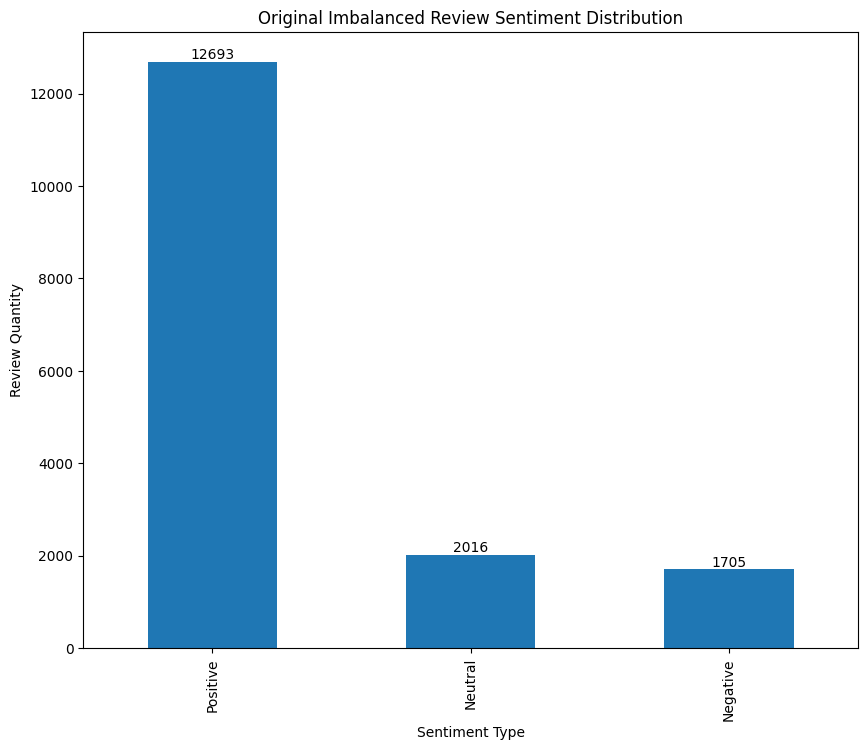

In [24]:
# original imbalanced 

mapping = {1: "Positive", -1: "Neutral", 0: "Negative"}

df_class = train_df['Label'].map(mapping).value_counts()

ax = df_class.plot(
    kind='bar',
    title='Original Imbalanced Review Sentiment Distribution',
    figsize=(10, 8),
    legend=False
)

ax.bar_label(ax.containers[0])
ax.set_xlabel("Sentiment Type")
ax.set_ylabel("Review Quantity");

### balance up the dataset

In [29]:
# balance up the proportion
avg_list = [
    train_df[train_df['Label'] == 0].index.size,
    train_df[train_df['Label'] == 1].index.size,
]
min_review_count = min(avg_list)
print(f"Min review count: {min_review_count}")

# each type use sample number of samples
df_goodlabel = train_df[train_df['Label'] == 1].sample(
    min_review_count, random_state=10)
df_neutrallabel = train_df[train_df['Label'] == -1].sample(
    min_review_count, random_state=10)
df_badlabel = train_df[train_df['Label'] == 0].sample(
    min_review_count, random_state=10)

df_balanced = pd.concat([df_goodlabel, df_badlabel], ignore_index=True)

Min review count: 1705


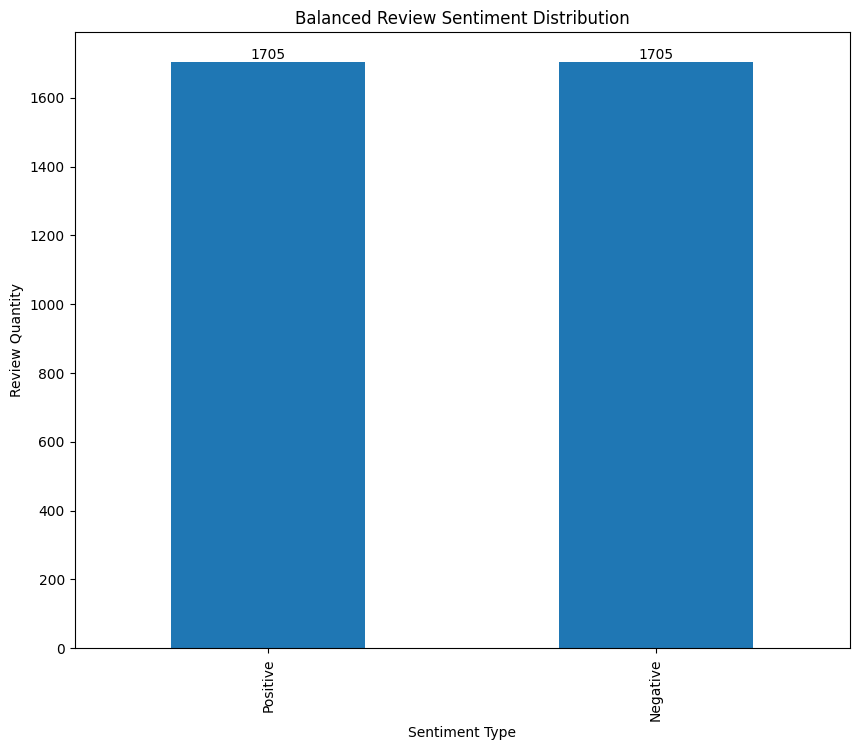

In [30]:
# Balanced dataset 

# original imbalanced 

mapping = {1: "Positive", 0: "Negative"}

df_class2 = df_balanced['Label'].map(mapping).value_counts()

ax = df_class2.plot(
    kind='bar',
    title='Balanced Review Sentiment Distribution',
    figsize=(10, 8),
    legend=False
)

ax.bar_label(ax.containers[0])
ax.set_xlabel("Sentiment Type")
ax.set_ylabel("Review Quantity");

## Machine Learning

In [31]:
# ========== Machine learing ============
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split


stopwordz = set(stopwords.words("English"))
stopwordz.remove('not') # remove negative


In [32]:
#update stopword to include malay
malay_stops = {
    # Pronouns & People
    'saya', 'kami', 'kita', 'mereka', 'dia', 'awak', 'kamu', 'ia', 'anda',
    
    # Prepositions & Connectives
    'yang', 'di', 'dan', 'ke', 'dari', 'pada', 'untuk', 'dengan', 'atau', 
    'serta', 'kerana', 'sebab', 'oleh', 'maka', 'hingga', 'sampai', 'tentang',
    
    # Demonstratives & Particles (Formal + Informal Slang)
    'ini', 'itu', 'ni', 'tu', 'lah', 'je', 'ja', 'jua', 'pun', 'ke', 'kan',
    
    # Verbs / Auxiliaries of Existence & Time
    'ada', 'adalah', 'ialah', 'telah', 'sudah', 'akan', 'pernah', 'sedang',
    'masih', 'boleh', 'dapat', 'hendak', 'mahu', 'nak', 'jadi',
    
    # High-Frequency Fillers
    'banyak', 'sangat', 'agak', 'amat', 'lagi', 'pula', 'seperti', 'paling'
}

# Combine them into a single set
bilingual_stopwords = list(stopwordz.union(malay_stops))

In [33]:
# Training Set
X_train = df_balanced['Review']
y_train = df_balanced['Label']

# Validation Set 
X_val = val_df['Review']
y_val = val_df['Label']

# Test Set 
X_test = test_df['Review']
y_test = test_df['Label']